## Import libraries


In [45]:
import os
from glob import glob

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

plt.rcParams["font.family"] = "DeJavu Serif"
plt.rcParams["font.serif"] = "Times New Roman"

import warnings

warnings.filterwarnings("ignore")

WORK_DIR = r"/beegfs/halder/GITHUB/PROJECT/HydroBlocks_DE"
RAW_DATA_DIR = os.path.join(WORK_DIR, "data", "raw")

## Read the region of interest


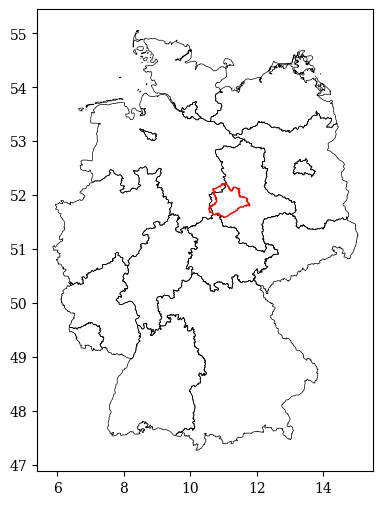

In [49]:
# Read the NUTS1 shapefile for DE
de_nuts1_gdf = gpd.read_file(
    os.path.join("/beegfs", "halder", "DATA", "DE_NUTS", "DE_NUTS_3.shp")
)
de_nuts1_gdf = de_nuts1_gdf[de_nuts1_gdf["LEVL_CODE"] == 1]
de_nuts1_gdf.rename(
    columns={"NUTS_ID": "STATE_ID", "NUTS_NAME": "STATE_NAME"}, inplace=True
)
de_nuts1_gdf.to_crs(crs="EPSG:4326", inplace=True)

# Read the Bode region
roi = gpd.read_file(os.path.join(RAW_DATA_DIR, "ROI", "Bode_catchment.zip"))
roi.to_crs(de_nuts1_gdf.crs, inplace=True)

fig, ax = plt.subplots(figsize=(6, 6))
de_nuts1_gdf.plot(ax=ax, facecolor="none", edgecolor="k", linewidth=0.5, label="NUTS1")
roi.plot(
    ax=ax,
    facecolor="none",
    edgecolor="r",
    linewidth=1,
    label="Bode Hydrological Observatory",
)

plt.show()

## Prepare grid cell


In [ ]:
roi.crs == "EPSG:4326"

True

In [ ]:
def create_grids(roi):
    assert roi.crs == "EPSG:4326", "Projection of the ROI"

<Axes: >

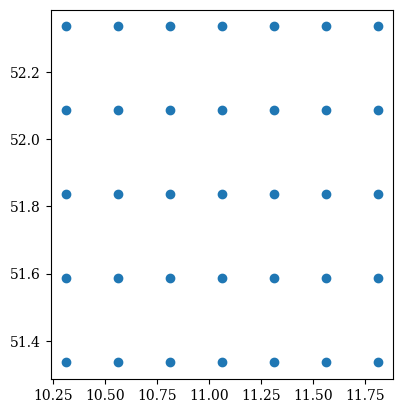

In [ ]:
# Create a mesh grid around the ROI
minx, miny, maxx, maxy = roi.total_bounds
lon = np.arange(minx - 0.25, maxx + 0.25, 0.25)
lat = np.arange(miny - 0.25, maxy + 0.25, 0.25)

lon_grid, lat_grid = np.meshgrid(lon, lat)

import geopandas as gpd
from shapely.geometry import Point

points = [Point(x, y) for x, y in zip(lon_grid.ravel(), lat_grid.ravel())]

grid_gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
grid_roi = gpd.clip(grid_gdf, roi)
grid_gdf.plot()

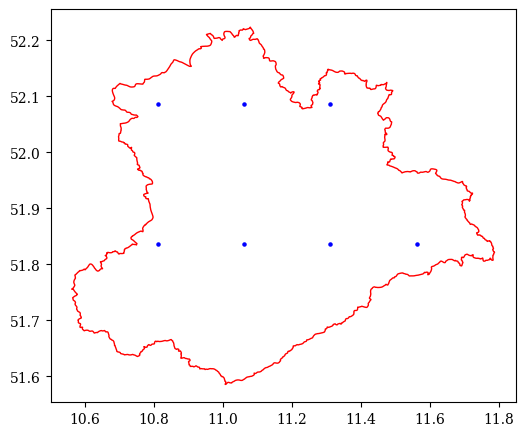

In [57]:
fig, ax = plt.subplots(figsize=(6, 6))

roi.plot(ax=ax, facecolor="none", edgecolor="red")
grid_roi.plot(ax=ax, markersize=5, color="blue")

plt.show()

## Prepare the topography and river network data
